In [7]:
import pyodbc

# Use pyodbc directly instead of SQLAlchemy for saving
conn2 = pyodbc.connect(
    'DRIVER={SQL Server};'
    'SERVER=AHMAD\\SQLEXPRESS;'
    'DATABASE=EcommerceDB;'
    'Trusted_Connection=yes;'
)

cursor = conn2.cursor()

# Drop table if it exists
cursor.execute("""
    IF OBJECT_ID('rfm_segments', 'U') IS NOT NULL
    DROP TABLE rfm_segments
""")

# Create the table
cursor.execute("""
    CREATE TABLE rfm_segments (
        customer_unique_id VARCHAR(100),
        recency_days INT,
        frequency INT,
        monetary FLOAT,
        R_score INT,
        F_score INT,
        M_score INT,
        Segment VARCHAR(50)
    )
""")

# Insert rows in batches
batch_size = 1000
rows = rfm[['customer_unique_id','recency_days','frequency',
            'monetary','R_score','F_score','M_score','Segment']].values.tolist()

for i in range(0, len(rows), batch_size):
    batch = rows[i:i+batch_size]
    cursor.executemany(
        "INSERT INTO rfm_segments VALUES (?,?,?,?,?,?,?,?)",
        batch
    )
    conn2.commit()

print(f"RFM table saved! {len(rows)} rows inserted.")
cursor.close()
conn2.close()

RFM table saved! 93358 rows inserted.


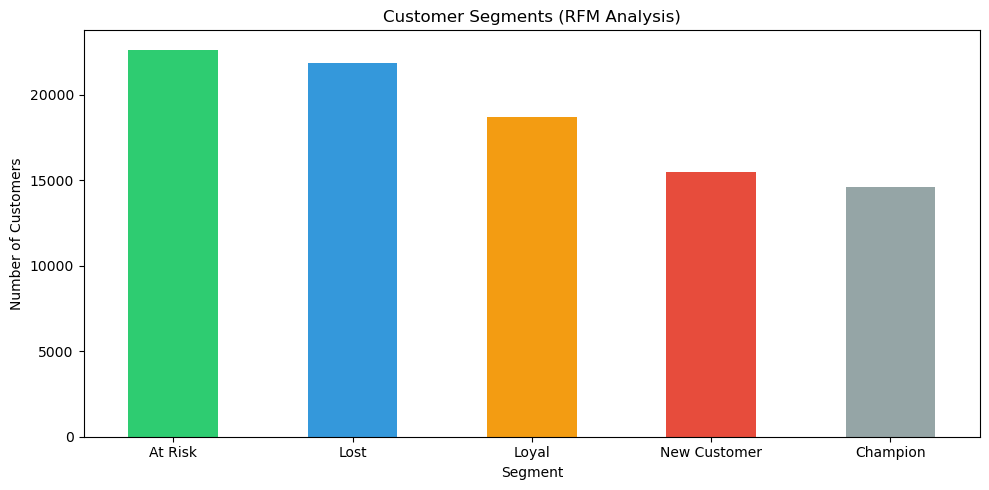

In [6]:
seg_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10, 5))
seg_counts.plot(kind='bar',
    color=['#2ecc71','#3498db','#f39c12','#e74c3c','#95a5a6'])
plt.title('Customer Segments (RFM Analysis)')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../output/rfm_segments.png')
plt.show()

In [5]:
def segment(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    if r >= 4 and f >= 4:
        return 'Champion'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'New Customer'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(segment, axis=1)
print(rfm['Segment'].value_counts())

Segment
At Risk         22647
Lost            21839
Loyal           18730
New Customer    15504
Champion        14638
Name: count, dtype: int64


In [4]:
import pandas as pd

rfm['R_score'] = pd.qcut(rfm['recency_days'], q=5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1,2,3,4,5])

print("Scores assigned!")
print(rfm[['customer_unique_id','R_score','F_score','M_score']].head())

Scores assigned!
                 customer_unique_id R_score F_score M_score
0  0a0a92112bd4c708ca5fde585afaa872       2       1       5
1  da122df9eeddfedc1dc1f5349a1a690c       1       5       5
2  763c8b1c9c68a0229c42c9fc6f662b93       5       1       5
3  dc4802a71eae9be1dd28f5d788ceb526       1       1       5
4  459bef486812aa25204be022145caa62       5       1       5


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

engine = create_engine(
    "mssql+pyodbc://AHMAD\\SQLEXPRESS/EcommerceDB"
    "?driver=SQL+Server&trusted_connection=yes"
)

with open('../sql/SQLQuery8.sql', 'r') as f:
    query = f.read()

rfm = pd.read_sql(query, engine)
print(f"RFM data loaded: {len(rfm)} customers")
print(rfm.head())

RFM data loaded: 93358 customers
                 customer_unique_id  recency_days  frequency  monetary
0  0a0a92112bd4c708ca5fde585afaa872           383          1   13440.0
1  da122df9eeddfedc1dc1f5349a1a690c           564          2    7388.0
2  763c8b1c9c68a0229c42c9fc6f662b93            94          1    7160.0
3  dc4802a71eae9be1dd28f5d788ceb526           612          1    6735.0
4  459bef486812aa25204be022145caa62            84          1    6729.0
